**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO _OPTIMIZE CLASSIFICATION DECISIONS BY TUNING PROBABILITY THRESHOLDS_. 🧠🎯📊**

This script demonstrates how to go beyond the default **0.5 threshold** and tune classification decisions based on real-world needs like improving **recall**, **precision**, or overall **F1-score**.

---

## **📦 Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

---

## **🧩 Load Dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

---

## **✂️ Split Data**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

---

## **🤖 Train Model**

In [4]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


---

## **📊 Get Prediction Probabilities**

In [5]:
y_probs = model.predict_proba(X_test)[:, 1]

---

## **🎯 Default Threshold (0.5)**

In [6]:
y_pred_default = (y_probs >= 0.5).astype(int)

print("=== Default Threshold (0.5) ===")
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall:", recall_score(y_test, y_pred_default))
print("F1 Score:", f1_score(y_test, y_pred_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_default))

=== Default Threshold (0.5) ===
Precision: 0.9375
Recall: 0.9813084112149533
F1 Score: 0.958904109589041
Confusion Matrix:
 [[ 57   7]
 [  2 105]]


---

## **🔁 Evaluate Multiple Thresholds**

In [7]:
thresholds = np.arange(0.1, 0.91, 0.1)

results = []

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

   threshold  precision    recall        f1
0        0.1   0.899160  1.000000  0.946903
1        0.2   0.930435  1.000000  0.963964
2        0.3   0.929825  0.990654  0.959276
3        0.4   0.929825  0.990654  0.959276
4        0.5   0.937500  0.981308  0.958904
5        0.6   0.945946  0.981308  0.963303
6        0.7   0.953704  0.962617  0.958140
7        0.8   0.971429  0.953271  0.962264
8        0.9   0.979167  0.878505  0.926108


---

## **📈 Visualize Threshold Impact**

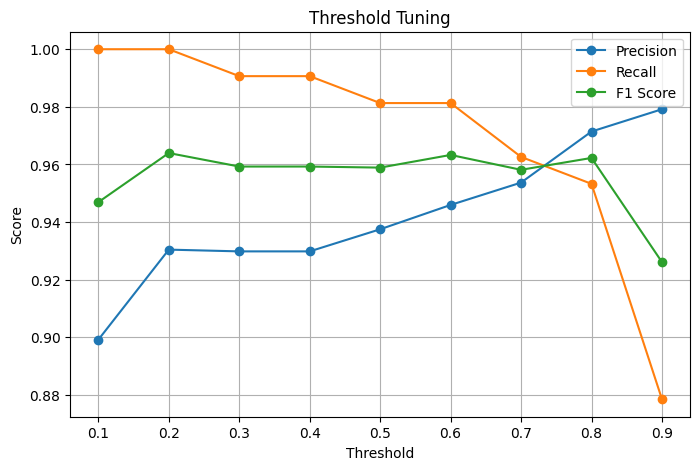

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(results_df["threshold"], results_df["precision"], marker="o", label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], marker="o", label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], marker="o", label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid(True)
plt.show()

---

## **✅ Select Best Threshold**

In [9]:
best_threshold = results_df.loc[results_df["f1"].idxmax(), "threshold"]

print("Best Threshold (F1):", best_threshold)

Best Threshold (F1): 0.2


---

## **🔍 Why Threshold Tuning Matters**

Default threshold = **0.5**, but:

- Fraud detection → prefer **high recall**
- Spam filtering → prefer **high precision**
- Medical diagnosis → minimize false negatives

Threshold tuning aligns model behaviour with **business goals**.

---

## **🧠 Key Takeaways**

1. Classification models output probabilities, not decisions.
2. The default 0.5 threshold is not always optimal.
3. Lower thresholds increase recall but reduce precision.
4. Higher thresholds increase precision but reduce recall.
5. Threshold tuning helps align ML with real-world requirements.

---

## **Conclusion**

Threshold tuning is a simple yet powerful technique that transforms how classification models are used in practice. By adjusting the decision boundary, we can tailor model behaviour to meet specific business needs instead of relying on generic defaults.

This strengthens your understanding in the **Advanced ML** track of the **AI with Python** series.

---